# Feature Detection, Matching, Segmentation

Nina Miolane, UC Santa Barbara

<center><img src="figs/03_main2.png" width=800px alt="default"/></center>


# Last Lectures

- **01: Image Formation Models (Ch. 2)**
- **02: Image Operators and Transforms (Ch. 3)**
- 03: Feature Detection, Matching, Segmentation (Ch. 7)
- 04: Image Alignment and Stitching (Ch. 8)
- 05: 3D Reconstruction (Ch. 13)

We have seen:
- how 2D images are acquired from a 3D scene,
- once acquired, which operations we can perform on them.

# This Lecture

- 01: Image Formation Models (Ch. 2)
- 02: Image Operators and Transforms (Ch. 3)
- **03: Feature Detection, Matching, Segmentation (Ch. 7)**
- 04: Image Alignment and Stitching (Ch. 8)
- 05: 3D Reconstruction (Ch. 13)

We will start using image processing tools, to:
- extract meaningful features from images,
- match features from pairs of images.

<center><img src="figs/03_main.png" width=300px alt="default"/></center>

# Vocabulary:

$\color{#EF5645}{\text{Features}}$ are characteristics extracted from the image such as points, edges, contours, lines, etc.

$\color{#EF5645}{\text{Matching}}$, also called alignment, correspondence, or registration, is the process of finding which features in one image are also present in another image.

<center><img src="figs/03_main2.png" width=700px alt="default"/></center>


Consider the two pairs of images shown in the Figure.

For the first pair:
- align the two images so that they can be seamlessly stitched into a composite mosaic?

For the second pair:
- establish a dense set of correspondences so that a 3D model can be constructed?

$\rightarrow$ what kinds of features should you detect and then match?


# Feature Detection, Matching, Segmentation

- **[Keypoint Detection and Matching](#sec-syllabus)**

- [Edges Detection](#sec-ece)

- [Contour Tracing](#sec-ece)

- [Segmentation Methods](#sec-ece)

# Keypoints and Keypoint Descriptors

$\color{#EF5645}{\text{Keypoints}}$, also called interest points or sometimes corners, are specific locations in the images such as mountain peaks, building corners, doorways, organ's anatomical landmarks, etc.

<center><img src="figs/03_faces.png" width=500px alt="default"/></center>

$\color{#EF5645}{\text{A keypoint descriptor}}$ is a vector that describes the appearance of the pixel patch around the keypoint. 

$\color{#047C91}{\text{Example}}$: Histogram of the intensities present around this keypoint.

# Why Keypoints and Descriptors?

- Object/people recognition (pre-deep learning or with small datasets). 
- Finding corresponding keypoints (=matching) in different images is useful for stitching, compute camera pose, perform 3D reconstruction.
    
<center><img src="figs/03_faces.png" width=600px alt="default"/></center>

# Keypoints Detection and Matching

Three steps:
- **Feature detection: Find keypoint location**
- Feature description: Compute keypoint descriptor
- Feature matching: Find corresponding keypoints in a pair of images

<center><img src="figs/03_pipeline.png" width=500px alt="default"/></center>

# Detection: Intuition

$\color{#EF5645}{\text{Goal}}$: Find keypoints, i.e. specific image locations that:
- **are easy to recognize and track,**
- will be helpful to perform matching between images.

<center><img src="figs/03_point_detection.png" width=800px alt="default"/></center>



# Detection: Intuition

<center><img src="figs/03_point_detection.png" width=600px alt="default"/></center>

$\color{#EF5645}{\text{Conclusion}}$: Contrast changes, i.e. gradients, are important:
- texture-less patches are almost impossible to localize,
- patches with large contrast changes (gradients) are easier,
- patches with gradient in at least two directions are the easiest.

# Detection: Intuition

$\color{#EF5645}{\text{Goal}}$: Find keypoints, i.e. specific image locations that:
- are easy to recognize and track,
- **will be helpful to perform matching between images.**

<center><img src="figs/03_invariance_geometry.png" width=450px alt="default"/></center>

$\color{#EF5645}{\text{Conclusion}}$: 
- Need invariance wrt geometric transformations or camera poses.

# Detection: Intuition

$\color{#EF5645}{\text{Goal}}$: Find keypoints, i.e. specific image locations that:
- are easy to recognize and track,
- **will be helpful to perform matching between images.**

<center><img src="figs/03_invariance_colors.png" width=800px alt="default"/></center>

$\color{#EF5645}{\text{Remarks}}$: 
- Need invariance with respect to lightning variations, coloring, noise, blur.

# Feature Detection: Desiderata

- Patch extraction needs to be repeatable and accurate
  - Invariant to translation, rotation, scale changes
  - Robust or covariant to out-ot-plane (affine) transformations
  - Robust to lighning variations, color histograms, noise or blur
- Quantity: Need a sufficient number of patches to cover the object
- Distinctiveness: Patch should contain interesting structure
- Efficiency: Fast enough to run in real-time

# Many Keypoint Detectors Available

- Hessian & Harris [Beaudet '78][Harris '88]
- Laplacian, DoG [Lindeberg '98][Lowe '99]
- Harris-/Hessian-Laplace [Mikolajczyk & Schmid '01]
- Harris-/Hessian-Affine [Mikolajczyk & Schmid '04]
- EBR and IBR [Tuytelaarss & Van Gool '04]
- MSER [Matas '02]
- Salient Regions [Kadir & Brady '01]
- Many others...

= Basic building blocks for many applications. We will see some of them.


# Harris Detector

$\color{#6D7D33}{\text{Intuition}}$:  If we shift a small window around keypoint, its content change radically.

<center><img src="figs/03_harris.png" width=400px alt="default"/></center>

$\color{#6D7D33}{\text{Math}}$:  Change of intensity for shift $(u, v)$ in image $I$:
$$ E_{AC}(u, v) = \sum_{x, y} w(x, y) \left( I(x+u, y+v) - I(x, y)\right)^2 \simeq (u, v)^T A (u, v),$$
- where $w$ are weights, also called the window function,
- $E_{AC}$ is known as the auto-correlation function,
- $A$ is the $\color{#EF5645}{\text{auto-correlation matrix}}$: $A = \sum_{x, y} w(x, y) \begin{bmatrix} I_x^2 & I_x I_y \\ I_x I_y & I_y^2 \end{bmatrix}$ with $I_x, I_y$ indicating derivatives in $x, y$.

# Approximation

Using a Taylor expansion: $I(x +u, y +v) \simeq I(x, y) + \nabla I (x, y)^T (u, v)$ we get:
$$\begin{align*}
E_{AC}(u, v)
&= \sum_{x, y} w(x, y) \left( I(x+u, y+v) - I(x, y)\right)^2 \\
&\simeq \sum_{x, y} w(x, y) \left( I(x, y) + \nabla I (x, y)^T (u, v) - I(x, y)\right)^2 \\
&= \sum_{x, y} w(x, y) \left(\nabla I (x, y)^T (u, v)\right)^2 \\
&= \sum_{x, y} w(x, y)  (u, v)^T \nabla I (x, y) \nabla I (x, y)^T (u, v)\\
&= (u, v)^T A(x, y) (u, v),
\end{align*}$$
where $A$ is the $\color{#EF5645}{\text{auto-correlation matrix}}$: $A = \sum_{x, y} w(x, y) \begin{bmatrix} I_x^2 & I_x I_y \\ I_x I_y & I_y^2 \end{bmatrix}$.

# Gradients of images

$\color{#EF5645}{\text{The gradient}}$ of the image $I$, written: 
$$\nabla I (x, y) = (I_x, I_y)(x, y) = \left(\frac{\partial I}{\partial x},\frac{\partial I}{\partial y} \right)(x, y), $$
is computed as:
- $\frac{\partial I}{\partial x}(x, y) = \lim_{dx \rightarrow 0} \frac{I(x + dx, y) - I(x, y)}{dx} \simeq \frac{I(x+1, y) - I(x-1,y)}{2}$
- $\frac{\partial I}{\partial y}(x, y) = \lim_{dy \rightarrow 0} \frac{I(x, y+dy) - I(x, y)}{dy} \simeq \frac{I(x, y+1) - I(x, y-1)}{2}$

<center><img src="figs/03_gradients.png" width=900px alt="default"/></center>

# $A$ for Axis-Aligned Corner

$\color{#047C91}{\text{Example}}$:  Axis-aligned corner.

<center><img src="figs/03_axis_aligned_corner.png" width=130px alt="default"/></center>

- The auto-correlation matrix $A$ writes, for some $\lambda_x, \lambda_y$:
$$A 
= \sum_{x, y} w(x, y) \begin{bmatrix} I_x^2 & I_x I_y \\ I_x I_y & I_y^2 \end{bmatrix}
= \begin{bmatrix}  \sum_{x, y} w(x, y) I_x^2 & \sum_{x, y} w(x, y)  I_x I_y \\ \sum_{x, y} w(x, y)  I_x I_y & \sum_{x, y} w(x, y)  I_y^2 \end{bmatrix}
= \begin{bmatrix} \lambda_x & 0 \\ 0 & \lambda_y \end{bmatrix}.$$


- Conversely, if $A$ is diagonal with large $\lambda$'s, there is an axis-aligned corner. 

# General A

Corners might not be axis-aligned.

<center><img src="figs/03_rotated_corner.jpg" width=200px alt="default"/></center>

- Since $A$ is symmetric, write eigenvalues decomposition (spectral theorem):
$$A 
= \begin{bmatrix}  \sum_{x, y} w(x, y) I_x^2 & \sum_{x, y} w(x, y)  I_x I_y \\ \sum_{x, y} w(x, y)  I_x I_y & \sum_{x, y} w(x, y)  I_y^2 \end{bmatrix}
= R^{-1} \begin{bmatrix} \lambda_1 & 0 \\ 0 & \lambda_2 \end{bmatrix} R,$$
for a rotation matrix $R$.

# Visualization of $A$

The eigenvalue decomposition of  $A$ allows us to visualize it as an ellipse:
- with axis lengths determined by the eigenvalues,
- with orientation determined by $R$, i.e. the eigenvectors.

<center><img src="figs/03_ellipse.png" width=700px alt="default"/></center>

# Classification of Image Locations with $A$

 Computing $A(x, y)$ for each location $(x, y)$:
- allows us to classify the type of points $(x, y)$ we are looking at.

<center><img src="figs/03_eigenvalues.png" width=750px alt="default"/></center>

However, computing an eigenvalue decomposition is computationally expensive.

# Corner Response Function $\theta$

Using determinant and trace of $A$: 
- gives us insights on the eigenvalues, without having to compute them.

$\color{#EF5645}{\text{The Corner Response Function}}$ is defined as:
$$\theta = \det(A) - \alpha \text{trace} (A)^2 = \lambda_1 \lambda_2 - \alpha (\lambda_1 + \lambda_2)^2.$$

$\color{#EF5645}{\text{Remarks}}$:
- Compute $\theta$ at each $(x, y)$.
- Constant $\alpha$ often taken between 0.04 and 0.06

# Harris Detector: Window Function $w$?

$\color{#EF5645}{\text{Recall}}$: The autocorrelation matrix $A$ depends on the choice of window function $w$:

$$A 
= \begin{bmatrix}  \sum_{x, y} w(x, y) I_x^2 & \sum_{x, y} w(x, y)  I_x I_y \\ \sum_{x, y} w(x, y)  I_x I_y & \sum_{x, y} w(x, y)  I_y^2 \end{bmatrix}.$$

$\color{#EF5645}{\text{Options for $w$:}}$ : Uniform window or smooth window with Gaussian kernel
<center><img src="figs/03_window.png" width=800px alt="default"/></center>


# Choose Window Function $w$?

- Option 1: Uniform window
  - $A = \sum_{x, y \text{ in window}} \begin{bmatrix}  I_x^2 & I_x I_y \\ I_x I_y & I_y^2 \end{bmatrix}$
  - Problem: not rotation invariant
  
- Option 2: Smooth with Gaussian Kernel
  - $A = g * \begin{bmatrix}  I_x^2 & I_x I_y \\ I_x I_y & I_y^2 \end{bmatrix}$
  - Rotation invariant: better!
  

$\color{#EF5645}{\text{Remark:}}$ The corner response function with Gaussian window $w$ writes:

$$\theta = g(I_x^2)g(I_y^2) - (g(I_x I_y))^2 - \alpha \left( g(I_x^2)+g(I_y^2)\right)^2.$$

# In practice: Harris Detector [Harris'88]

$g$ refer to the window $w$, which is Gaussian by convention.

<center><img src="figs/03_summary_harris.png" width=350px alt="default"/></center>

<center><img src="figs/03_theta.png" width=350px alt="default"/></center>




In [31]:
from matplotlib import pyplot as plt

from skimage import data
from skimage.color import rgb2gray
from skimage.feature import corner_harris, corner_subpix, corner_peaks
from skimage.transform import warp, AffineTransform
from skimage.draw import ellipse

# Example: Create an Image

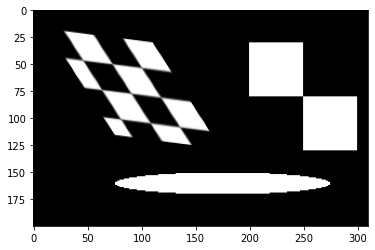

In [70]:
image_geom = data.checkerboard()[:90, :90]

# # Sheared checkerboard
tform = AffineTransform(scale=(1.3, 1.1), rotation=1, shear=0.7, translation=(110, 30))
image_geom = warp(image_geom, tform.inverse, output_shape=(200, 310))

# Ellipse
rr, cc = ellipse(160, 175, 10, 100)
image_geom[rr, cc] = 1

# Two squares
image_geom[30:80, 200:250] = 1; image_geom[80:130, 250:300] = 1

fig, ax = plt.subplots()
ax.imshow(image_geom, cmap=plt.cm.gray);

# Example: Compute corners With Harris Detector

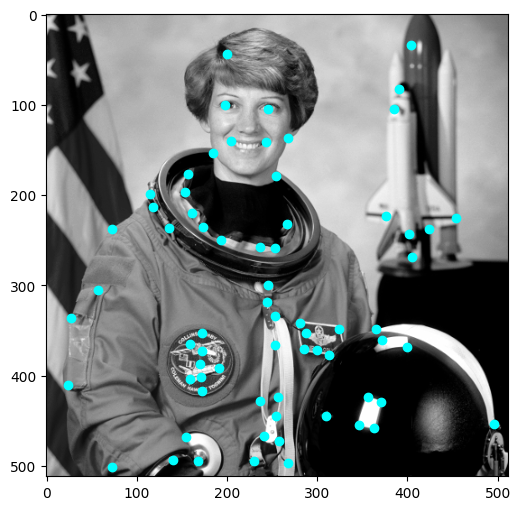

In [39]:
#image = data.astronaut()[:, :, ] # rgb2gray(data.astronaut())
image = rgb2gray(data.astronaut())
#print(image.shape)
coords = corner_peaks(corner_harris(image), min_distance=10, threshold_rel=0.02)

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(image, cmap=plt.cm.gray)
ax.plot(
    coords[:, 1], coords[:, 0], # NB: coordinates are inverted!
    color='cyan', marker='o',linestyle='None', markersize=6)
plt.show()

# An Alternative: Hessian Detector

$\color{#EF5645}{\text{The Hessian}}$ of image $I$ is the matrix of the second derivatives of $I$:
$$H(I)(x, y) = \begin{bmatrix} I_{xx} & I_{xy} \\ I_{xy} & I_{yy} \end{bmatrix}.$$


$\color{#EF5645}{\text{Hessian Detector}}$ searches for strong derivatives in both $x$ and $y$ directions.
- Compute $\det H(I)  = I_{xx}I_{yy} - I_{xy}^2$
- Select point $(x, y)$ where:
  - $\det H(I)(x, y) >$ threshold.

<center><img src="figs/03_hessian.png" width=350px alt="default"/></center>

- Compute $\det H(I)(x, y)$

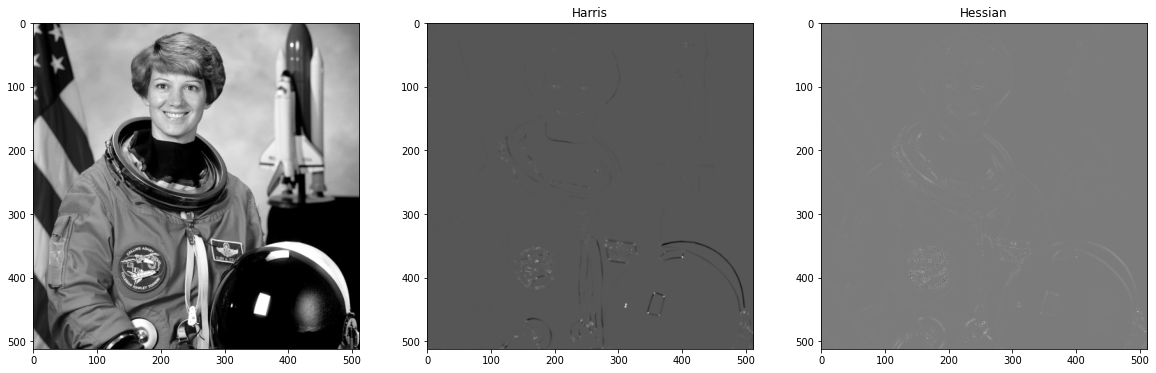

In [95]:
from skimage.feature import hessian_matrix_det

image = rgb2gray(data.astronaut())
#image = image_geom

thetas = corner_harris(image)
dets = hessian_matrix_det(image)

fig, axes = plt.subplots(ncols=3, figsize=(20, 6))
axes[0].imshow(image, cmap=plt.cm.gray);
axes[1].imshow(thetas, cmap=plt.cm.gray); axes[1].set_title("Harris")
axes[2].imshow(-dets, cmap=plt.cm.gray); axes[2].set_title("Hessian");

- Select point $(x, y)$ where $\det H(I)(x, y) >$ threshold.

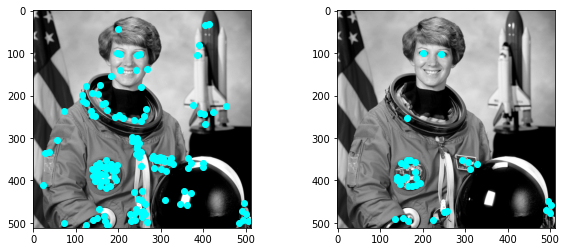

In [97]:
coords_harris = corner_peaks(corner_harris(image), min_distance=5, threshold_rel=0.02)
coords_hessian = corner_peaks(hessian_matrix_det(image), min_distance=5, threshold_rel=0.2)

fig, ax = plt.subplots(ncols=2, figsize=(10, 4))
ax[0].imshow(image, cmap=plt.cm.gray)
ax[0].plot(
    coords_harris[:, 1], coords_harris[:, 0], 
    color='cyan', marker='o', linestyle='None', markersize=6)
ax[1].imshow(image, cmap=plt.cm.gray)
ax[1].plot(
    coords_hessian[:, 1], coords_hessian[:, 0],
    color='cyan', marker='o', linestyle='None', markersize=6)
plt.show()

# An Alternative: Difference of Gaussians (DoG)

$\color{#EF5645}{\text{Recall}}$: one step of the Laplacian pyramid: difference of Gaussians.

- Compute: $DoG(x, y) = g_\sigma^L * I - g_\sigma^H * I$
- Select point $(x, y)$:
  - for $DoG(x, y) >$ threshold

<center><img src="figs/02_laplace_block.png" width=300px alt="default"/></center>

In [18]:
from skimage.filters import difference_of_gaussians

- Compute $DoG(x, y)$
- Select points $(x, y)$ such that $DoG(x, y) >$ threshold

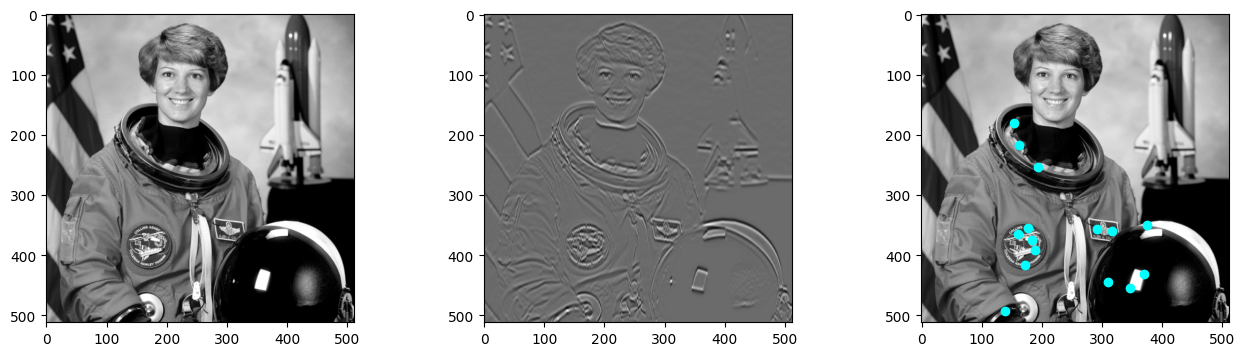

In [19]:
diff_of_g = difference_of_gaussians(image=image, low_sigma=2, high_sigma=2.6, channel_axis=-1)
coords_dog = corner_peaks(diff_of_g, min_distance=10, threshold_rel=0.6)

fig, ax = plt.subplots(ncols=3, figsize=(16, 4))
ax[0].imshow(image, cmap=plt.cm.gray)
ax[1].imshow(diff_of_g, cmap=plt.cm.gray)
ax[2].imshow(image, cmap=plt.cm.gray)
ax[2].plot(coords_dog[:, 1], coords_dog[:, 0], color='cyan', marker='o',
        linestyle='None', markersize=6)
plt.show()

# Invariances

Harris Detection is invariant to:
- Illumination changes
- Translation
- Rotation

But not to scaling.


<center><img src="figs/03_scal.png" width=800px alt="default"/></center>

# Towards Detectors that are Scale Invariant

Consider regions (e.g. circles) of different sizes around a point in the image:
- Regions of corresponding sizes will look the same in both images
- How to find corresponding circles, independently in both images?

<center><img src="figs/03_scal_inv.png" width=400px alt="default"/></center>

$\rightarrow$ Go multiscale with pyramids.

# Naive Scale Invariant Detection

Consider two images:
- Compute Gaussian pyramid of both 
- Performing N × N pairwise comparisons to find the best match. 

<center><img src="figs/03_gaussian_pyr.png" width=550px alt="default"/></center>

But too expensive to be of practical use.

# Scale-Invariant Detection

$\color{#6D7D33}{\text{Solution}}$: Compute "scale-invariant" keypoint directly from __one__ image:
- Define a function $f$ on the region (circle) which is "scale-invariant":
  - Same for corresponding regions even if they are at different scales, e.g.: average intensity
  - For point $(x, y)$: $f_{x, y}$ is function of region size (circle radius).
- For each $(x, y)$, find local maximum of $f$. If maximum: keypoint!

$\rightarrow$ Region size, for which the maximum is achieved, is invariant to image scale.

<center><img src="figs/03_scal_inv_function.png" width=800px alt="default"/></center>

# Good $f$ for Scale Invariant Detection?

= function that has one stable sharp peak, e.g.  that responds to contrast (sharp local intensity changes): gradients!

<center><img src="figs/03_scal_inv_options.png" width=1600px alt="default"/></center>

# Scale Invariant Detector with Laplacian Pyramid

Laplacian Pyramid: take $f$ to be the difference of Gaussians at each level

<center><img src="figs/03_ateachpoint.png" width=400px alt="default"/></center>

# Example: Consider a Keypoint

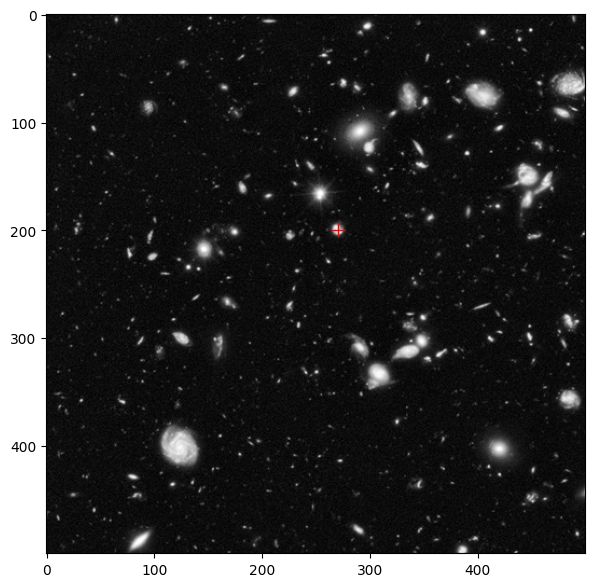

In [41]:
x0, y0 = 270, 200 #123, 401 #270, 200 
image = rgb2gray(data.hubble_deep_field()[0:500, 0:500])
fig, ax = plt.subplots(1, 1, figsize=(7,7))

ax.imshow(image, cmap=plt.cm.gray)
ax.plot(x0, y0, color="red", marker="+", markersize=10);

# Compute Pyramid

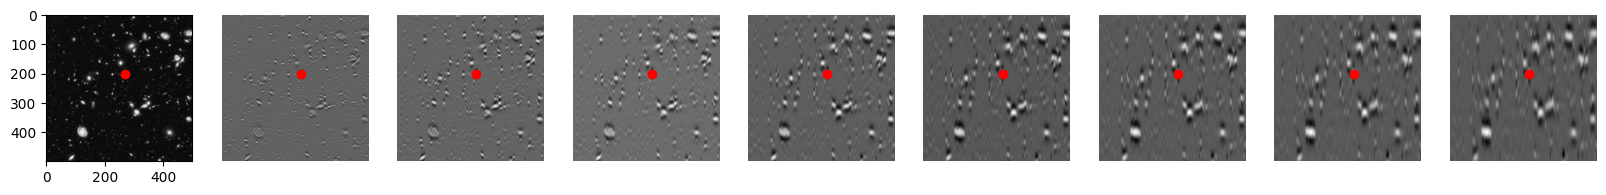

In [46]:
import numpy as np

image_pyramid = []
sigmas = np.arange(1, 16, 2)

fig, axes = plt.subplots(ncols=len(sigmas)+1, figsize=(20, 6))
axes[0].imshow(image, cmap=plt.cm.gray)
axes[0].plot(x0, y0, color="red", marker="o");
for i, sigma in enumerate(sigmas):
    diff_of_g = difference_of_gaussians(
        image=image, low_sigma=sigma, high_sigma=sigma+3, channel_axis=-1)
    axes[i+1].imshow(diff_of_g, cmap=plt.cm.gray)
    axes[i+1].plot(x0, y0, color='red', marker='o', linestyle='None', markersize=6)
    axes[i+1].axis("off")
    image_pyramid.append(diff_of_g)

# Visualize $f$ at the Keypoint

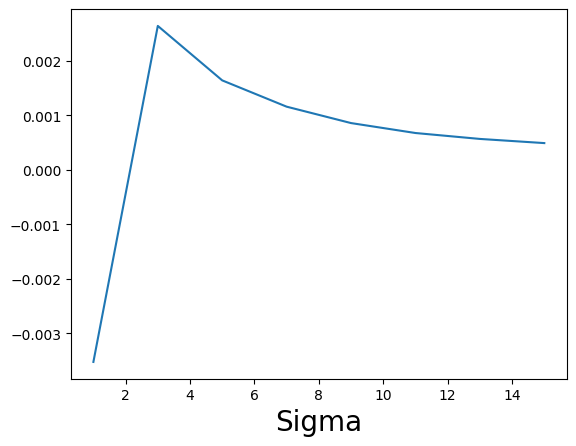

In [47]:
# f gives the value of the diff of gaussians
plt.plot(sigmas, [el[x0, y0] for el in image_pyramid])
plt.xlabel("Sigma", fontsize=20);

# Keypoint's Characteristic Scale

$\color{#EF5645}{\text{The characteristic scale}}$ is the scale that produces the peak of response in DoG.

<center><img src="figs/03_scale.png" width=800px alt="default"/></center>

# Scale Invariant Detectors


<center><img src="figs/03_detectors.png" width=950px alt="default"/></center>



$\color{#EF5645}{\text{Remark}}$: Laplacian pyramid that we introduced with DoG:
- only a fast approximation of the true Laplacian Pyramid.



# Summary: Find Keypoint Location

- $\color{#6D7D33}{\text{Given}}$: Two images of the same scene with a large scale  difference between them.

- $\color{#6D7D33}{\text{Goal}}$: Find the same keypoints independently in each image. 

- $\color{#6D7D33}{\text{Solution}}$:  Search for maxima of suitable $f$ in scale and in space.

In [ ]:
- Two strategies...
  - Laplacian‐of‐Gaussian (LoG) 
  - Difference‐of‐Gaussian (DoG) as a fast approximation 

...used on their own or with single-scale keypoint detectors (Harris, Hessian)

# Keypoints Detection and Matching

Three steps:
- Feature detection: Find keypoint location
- **Feature description: Compute keypoint descriptor**
- Feature matching: Find corresponding keypoints in a pair of images

<center><img src="figs/03_pipeline.png" width=500px alt="default"/></center>

# Intensity Patches (normalized)

$\color{#EF5645}{\text{Intensity patches}}$, normalized for 0 mean and 1 standard deviation, can sometimes perform reasonably, if the two images are not too different.

<center><img src="figs/03_MOPS.png" width=600px alt="default"/></center>


$\color{#EF5645}{\text{Remarks}}$: In most cases, however:
- the local appearance of features will change in orientation and scale, or affine deformations. 

$\rightarrow$ Keypoint descriptor should also be invariant to transformations!

# SIFT Descriptor

SIFT Descriptor = Scale-Invariant Feature Transform Descriptor

$\color{#6D7D33}{\text{Method}}$:
1. Compute image gradient at each pixel in a 16 x 16 window around the key point $(x, y)$.

<center><img src="figs/03_sift_descriptor.png" width=600px alt="default"/></center>


# SIFT Descriptor

$\color{#6D7D33}{\text{Method}}$:

2. Downweight gradients' magnitude with Gaussian weights to reduce influence of gradients far from keypoint $(x, y)$

<center><img src="figs/03_sift_descriptor.png" width=800px alt="default"/></center>


# SIFT Descriptor

$\color{#6D7D33}{\text{Method}}$:

3. In each 4 x 4 quadrant, form a 8-bin (weighted) gradient orientation histogram
  
 <center><img src="figs/03_sift_descriptor.png" width=800px alt="default"/></center>

# SIFT Descriptor

$\color{#6D7D33}{\text{Method}}$:

4. Stack 4x4 array of 8-bin histogram, and normalize to get unit-norm
  - SIFT descriptor = unit vector of 128 non-negative values
  
 <center><img src="figs/03_sift_descriptor.png" width=600px alt="default"/></center>

$\color{#EF5645}{\text{Remark}}$: Many variants exist: PCA-SIFT, RootSIFT, etc.

# Summary: A Scale Invariant Descriptor

- $\color{#6D7D33}{\text{Given}}$: One image and a given keypoint $(x, y)$

- $\color{#6D7D33}{\text{Goal}}$: Find a descriptor of $(x, y)$ that is scale invariant. 

- $\color{#6D7D33}{\text{Solution}}$: The SIFT descriptor, as an histogram of gradients, provides a scale-invariant descriptor.

# Keypoints Detection and Matching

Three steps:
- Feature detection: Find keypoint location
- Feature description: Compute keypoint descriptor
- **Feature matching: Find corresponding keypoints in a pair of images**

<center><img src="figs/03_pipeline.png" width=500px alt="default"/></center>

# Matching

$\color{#EF5645}{\text{Matching}}$ means to determine which features come from corresponding locations in different images.

# Matching Assumptions

Assume that:
- Descriptors are vectors of the same length $D_1, D_2, ...$, e.g. SIFT descriptors
- Descriptors can be compared w. Euclidean distance: :
  - $||D_1 - D_2||$ small means patches around descriptors $D_1, D_2$ are similar: a potential match!
 

# Matching Strategy

Assumption: Descriptors are vectors $D$ of the same length, e.g. SIFT descriptors (length 128).

$\color{#6D7D33}{\text{Method}}$: Set a threshold, and:
- For each image:
    - For each descriptor $D$ in this image:
        - compute Euclidean distance between $D$ and all descriptors $D'$ of all other images
        - If $||D - D'||$  < threshold: potential match!
    

# Matching Errors

$\color{#EF5645}{\text{Remarks}}$:
- Threshold too high: lots of false positives
- Threshold too low: lots of false negatives

<center><img src="figs/03_matching.png" width=1000px alt="default"/></center>

# Matching Evaluation

$\color{#EF5645}{\text{The confusion matrix}}$: is a good tool to evaluate if the matching worked.

<center><img src="figs/03_confusion.png" width=1200px alt="default"/></center>

# Example: Matching with SIFT

In [2]:
import matplotlib.pyplot as plt

from skimage import data
from skimage import transform
from skimage.color import rgb2gray
from skimage.feature import match_descriptors, plot_matches, SIFT

# Example: Generate 3 Images

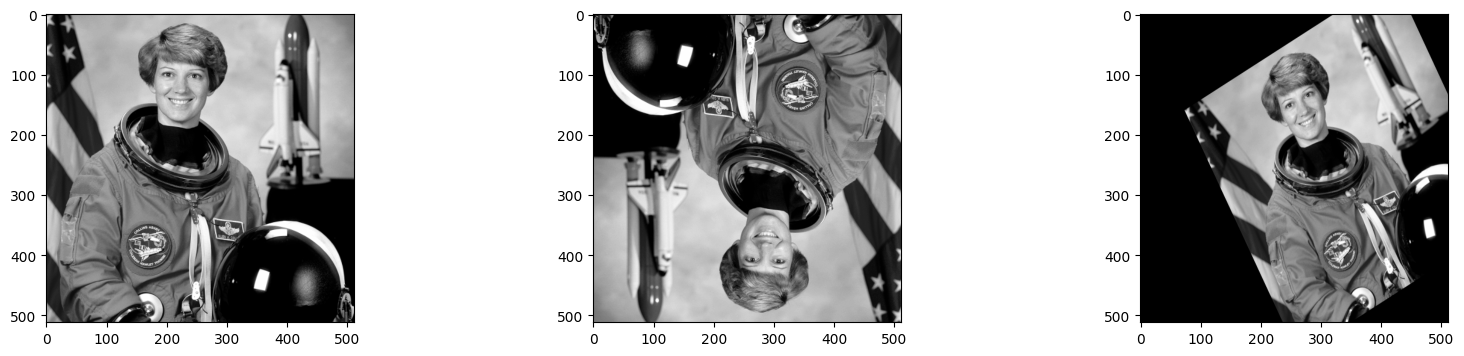

In [6]:
img1 = rgb2gray(data.astronaut())
img2 = transform.rotate(img1, 180)
tform = transform.AffineTransform(scale=(1.3, 1.1), rotation=0.5, translation=(0, -200))
img3 = transform.warp(img1, tform)

fig, axes = plt.subplots(ncols=3, figsize=(20, 4))
axes[0].imshow(img1, cmap=plt.cm.gray)
axes[1].imshow(img2, cmap=plt.cm.gray)
axes[2].imshow(img3, cmap=plt.cm.gray);

# Example: Extract SIFT descriptors

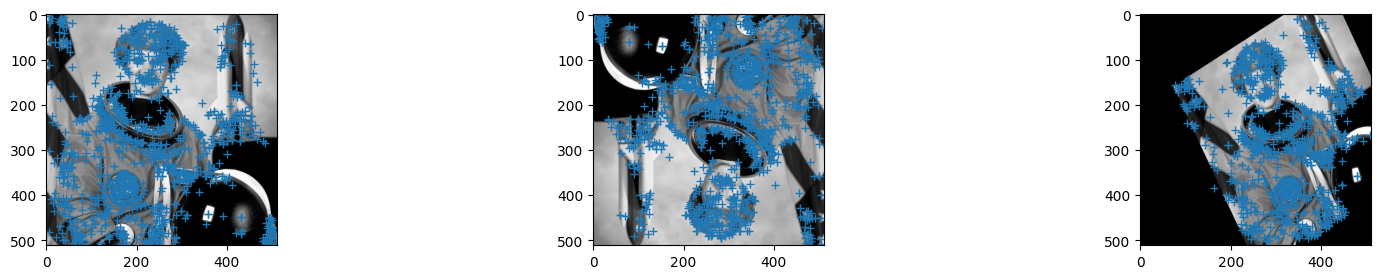

In [7]:
descriptor_extractor = SIFT()

descriptor_extractor.detect_and_extract(img1)
keypoints1 = descriptor_extractor.keypoints
descriptors1 = descriptor_extractor.descriptors

descriptor_extractor.detect_and_extract(img2)
keypoints2 = descriptor_extractor.keypoints
descriptors2 = descriptor_extractor.descriptors

descriptor_extractor.detect_and_extract(img3)
keypoints3 = descriptor_extractor.keypoints
descriptors3 = descriptor_extractor.descriptors

fig, axes = plt.subplots(ncols=3, figsize=(20, 3))
axes[0].imshow(img1, cmap=plt.cm.gray); axes[0].plot(keypoints1[:, 1], keypoints1[:, 0], marker="+", linestyle='None')
axes[1].imshow(img2, cmap=plt.cm.gray); axes[1].plot(keypoints2[:, 1], keypoints2[:, 0], marker="+", linestyle='None')
axes[2].imshow(img3, cmap=plt.cm.gray); axes[2].plot(keypoints3[:, 1], keypoints3[:, 0], marker="+", linestyle='None');

# Example: Match Descriptors

In [17]:
matches12 = match_descriptors(
    descriptors1, descriptors2, max_ratio=0.6, cross_check=True)
matches13 = match_descriptors(
    descriptors1, descriptors3, max_ratio=0.6, cross_check=True)
print(matches12.shape)
print(matches12[:5])

(1126, 2)
[[   0  564]
 [   1 1133]
 [   2  562]
 [   3  561]
 [   4  560]]


# Example: Plot the Results

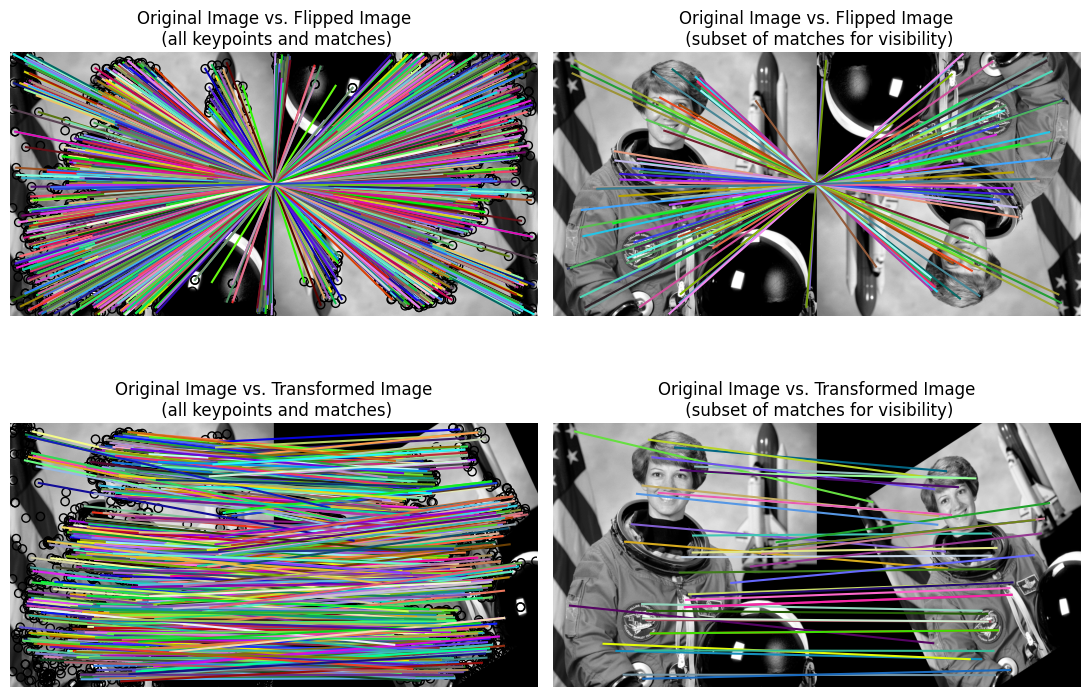

In [29]:
fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(11, 8)); plt.gray()
plot_matches(ax[0, 0], img1, img2, keypoints1, keypoints2, matches12)

ax[0, 0].axis('off'); ax[0, 0].set_title("Original Image vs. Flipped Image\n (all keypoints and matches)")
plot_matches(ax[1, 0], img1, img3, keypoints1, keypoints3, matches13)
ax[1, 0].axis('off'); ax[1, 0].set_title("Original Image vs. Transformed Image\n (all keypoints and matches)")
plot_matches(ax[0, 1], img1, img2, keypoints1, keypoints2, matches12[::15], only_matches=True)
ax[0, 1].axis('off'); ax[0, 1].set_title("Original Image vs. Flipped Image\n (subset of matches for visibility)")
plot_matches(ax[1, 1], img1, img3, keypoints1, keypoints3, matches13[::15], only_matches=True)
ax[1, 1].axis('off'); ax[1, 1].set_title("Original Image vs. Transformed Image\n (subset of matches for visibility)")
plt.tight_layout(); plt.show()

# Feature Detection, Matching, Segmentation

- [Keypoint Detection and Matching](#sec-syllabus)

- **[Edges Detection](#sec-ece)**

- **[Contour Tracing](#sec-ece)**

- [Segmentation Methods](#sec-ece)

# Why Edges and Contours?

Last lecture: $\color{#EF5645}{\text{Keypoints}}$:
- Find image locations that can be accurately matched.
- No semantic information, no understanding of the image scene.


<center><img src="figs/03_main2.png" width=700px alt="default"/></center>


# Why Edges and Contours?


This lecture: $\color{#EF5645}{\text{Edges and Contours}}$:
- Find semantic information, as edges correspond to:
  - discontinuities in depth (different objects),
  - discontinuities in surface orientation (shapes of objects),
  - changes in material properties (texture of objects), etc.
- Reduce the amount of data to be processed for image interpretation
    - filter out irrelevant information, keep important structural properties 

$\color{#047C91}{\text{Example}}$: Young children easily recognize familiar objects by line drawings.


# Why Edges and Contours?

$\color{#047C91}{\text{Applications of Edges and Contours Detection}}$:
- Finger print matching
- Medical imaging diagnosis
- License plate detection

<center><img src="figs/03_prints.jpeg" width=600px alt="default"/></center>

# Why Edges and Contours?

$\color{#047C91}{\text{Applications of Edges and Contours Detection}}$:
- Finger print matching
- Medical imaging diagnosis
- License plate detection

<center><img src="figs/03_medical.jpeg" width=700px alt="default"/></center>

# Why Edges and Contours?

$\color{#047C91}{\text{Applications of Edges and Contours Detection}}$:
- Finger print matching
- Medical imaging diagnosis
- License plate detection

<center><img src="figs/03_plate.png" width=600px alt="default"/></center>

# Edges and Contours: Humans v. Machines

- Humans have no problem detecting edges:
  - _"Divide the image into some number of segments, where the segments represent ’things’ or ’parts of things’ in the scene. The number of segments is up to you, as it depends on the image. Something between 2 and 30 is likely to be appropriate. It is important that all of the segments have approximately equal importance."_
  <center><img src="figs/03_human_edges.png" width=600px alt="default"/></center>
  
  - Edge detection is machine processing can be a complicated task.


# Edges and Contours

$\color{#EF5645}{\text{Edges}}$ are significant local changes of intensity in a digital image. Edges are a set of connected pixels that forms a boundary between two disjoint regions. Edges may or may not form a closed shape. 

$\color{#EF5645}{\text{Contours}}$ are a set of connected pixels with the same intensity that forms a closed shape defining the boundary of an object.


<center><img src="figs/03_human_edges.png" width=800px alt="default"/></center>

# Feature Detection, Matching, Segmentation

- [Keypoint Detection and Matching](#sec-syllabus)

- **[Edges Detection](#sec-ece)**

- **[Contour Tracing](#sec-ece)**

- [Segmentation Methods](#sec-ece)

# Recall: Edges and Contours
$\color{#EF5645}{\text{Edges}}$ are significant local changes of intensity in a digital image. Edges are a set of connected pixels that forms a boundary between two disjoint regions. Edges may or may not form a closed shape. 

$\color{#EF5645}{\text{Contours}}$ are a set of connected pixels with the same intensity that forms a **closed shape** defining the boundary of an object.


<center><img src="figs/03_human_edges.png" width=700px alt="default"/></center>

# Contours and Segmentation


$\color{#EF5645}{\text{Contours}}$ are a set of connected pixels with the same intensity that forms a **closed shape** defining the boundary of an object.

$\color{#EF5645}{\text{Image segmentation}}$ is the process of dividing an image into different regions based on the characteristics of pixels to identify objects or boundaries to simplify an image and more efficiently analyze it.

<center><img src="figs/03_human_edges.png" width=700px alt="default"/></center>

# Applications: Contours \& Segmentation

Active contours can be seen as the segmentation and identification of 1 region.

$\color{#047C91}{\text{Example}}$: Brain tumor segmentation:
- helps predicting tumor growth,
- is crucial for radiotherapy planning (cancer treatment that uses high doses of radiation to kill cancer cells and shrink tumors).

<center><img src="figs/03_snake_brain.png" width=450px alt="default"/></center>

# Applications: Contours \& Segmentation

Active contours can be seen as the segmentation and identification of 1 region.

$\color{#047C91}{\text{Example}}$: Lips segmentation:
- helps algorithms translating lips movements into text.

<center><img src="figs/03_lips.png" width=700px alt="default"/></center>

# Contours and Segmentation


$\color{#EF5645}{\text{Contours}}$ are a set of connected pixels with the same intensity that forms a **closed shape** defining the boundary of an object: "segmentation of one region"

$\color{#EF5645}{\text{Image segmentation}}$ is the process of dividing an image into different regions based on the characteristics of pixels to identify objects or boundaries.


<center><img src="figs/03_human_edges.png" width=700px alt="default"/></center>

# Segmentation

$\color{#EF5645}{\text{Image segmentation}}$ is the process of dividing an image into different regions based on the characteristics of pixels to identify objects or boundaries.


<center><img src="figs/03_intro_seg1.png" width=800px alt="default"/></center>

The different regions are called $\color{#EF5645}{\text{segments}}$.

# Types of Segmentation

$\color{#EF5645}{\text{Semantic segmentation}}$ gives a label to each segment.

<center><img src="figs/03_intro_seg2.png" width=800px alt="default"/></center>

# Types of Segmentation

$\color{#EF5645}{\text{Foreground/Background segmentation}}$ divides the image into two segment: foreground and background.

<center><img src="figs/03_intro_seg3.png" width=700px alt="default"/></center>

# Related to Segmentation

<center><img src="figs/03_seg_types.png" width=900px alt="default"/></center>

# Importance of Segmentation

Segmentation allows us to simplify a downstream task, such as classification. For example, it can increase classification accuracy.

<center><img src="figs/03_intro_seg4.png" width=500px alt="default"/></center>

# Applications of Segmentation

- Content based image retrieval
- Medical imaging (tumor segmentation)
- Object detection (face detection)
- 3D reconstruction
- Object tracking, object recognition
- Object-based measurements such as size and shape
- Video surveillance
- etc.

$\rightarrow$ one of the oldest and most widely studied problems.

# Many Segmentation Algorithms

Segmentation methods can be divided into several classes:
- Thresholding
- Region-based methods (region growing, etc)
- Clustering (k-means, GMMs, mean-shift, etc)
- Graph-based methods (graph-cut, random walk, etc)
- Shape based methods (active contours)
- Energy minimization methods (MRF)
- Machine learning and deep learning methods.

$\rightarrow$ we will see some of these.

# This Unit

- 01: Image Formation Models (Ch. 2)
- 02: Image Operators and Transforms (Ch. 3)
- **03: Feature Detection, Matching, Segmentation (Ch. 7)**
- 04: Image Alignment and Stitching (Ch. 8)
- 05: 3D Reconstruction (Ch. 13)